100%|██████████| 100/100 [23:53<00:00, 14.33s/it]


SHAP values have been saved.


ModuleNotFoundError: No module named 'google.colab'

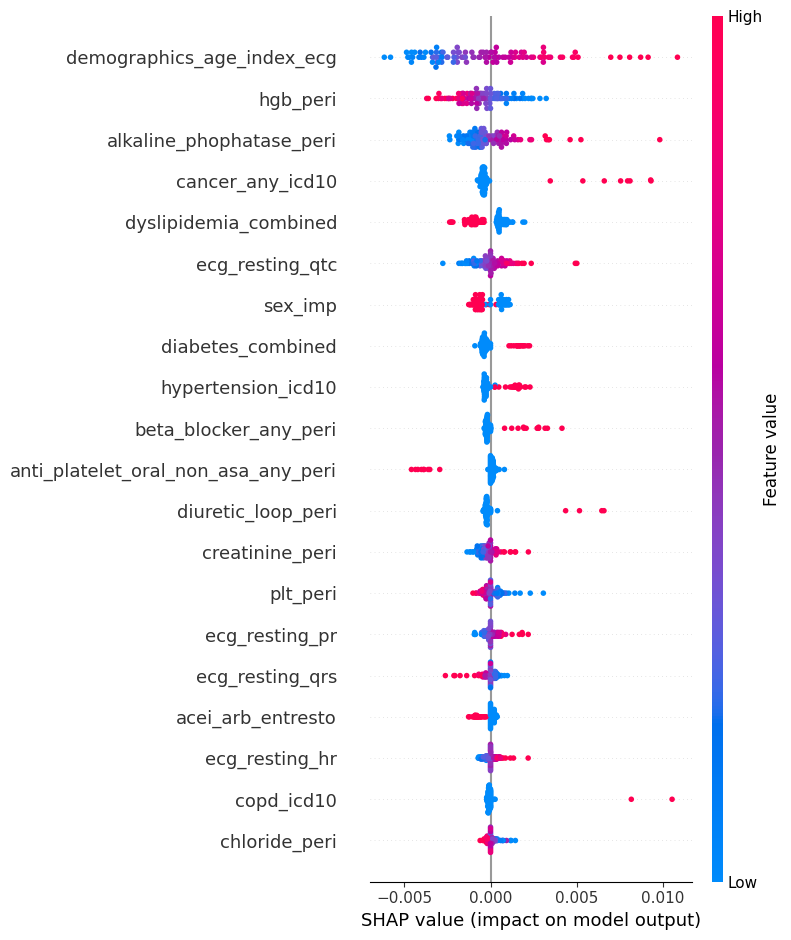

In [4]:
#!pip install pycox torchtuples einops tab-transformer-pytorch shap
import shap
import torch.nn.functional as F
import matplotlib.pyplot as plt

import os
os.chdir('/home/UT_shared/data/')

import pandas as pd
df_train = pd.read_csv("train.csv")
df_val = pd.read_csv("val.csv")
df_test = pd.read_csv("test.csv")

"""Data Preprocessing"""

import torch
import numpy as np

categ_idx = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,
    17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
    31, 32, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,
    60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
    74, 79, 75, 76
]
cont_idx = [
    0, 33, 34, 35, 36,
    48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59
]
x_cat_test = torch.tensor(df_test.iloc[:, categ_idx].to_numpy(), dtype=torch.long)
x_cont_test = torch.tensor(df_test.iloc[:, cont_idx].to_numpy(), dtype=torch.float32)

feature_names = df_test.columns[categ_idx + cont_idx].tolist()
X_all = df_test.iloc[:, categ_idx + cont_idx].to_numpy()

# Categories for TabTransformer (num unique per categorical column)
categories = [int(df_train.iloc[:, idx].max()) + 1 for idx in categ_idx]

"""Load Model"""

import torchtuples as tt
import torch.nn as nn
from einops import rearrange, repeat
from tab_transformer_pytorch import TabTransformer as BaseTabTransformer
from torch.serialization import add_safe_globals

def exists(val):
    return val is not None
    
# Rebuild tabTransformer with embedding return
class TabTransformerwithEmbedding(BaseTabTransformer):
    def forward(self, x_categ, x_cont, return_attn=False, return_embedding=False):
        xs = []

        assert x_categ.shape[-1] == self.num_categories
        if self.num_unique_categories > 0:
            x_categ = x_categ + self.categories_offset
            categ_embed = self.category_embed(x_categ)

            if self.use_shared_categ_embed:
                shared_categ_embed = repeat(
                    self.shared_category_embed, 
                    'n d -> b n d', 
                    b=categ_embed.shape[0]
                )
                categ_embed = torch.cat((categ_embed, shared_categ_embed), dim=-1)

            x, attns = self.transformer(categ_embed, return_attn=True)
            flat_categ = rearrange(x, 'b ... -> b (...)')
            xs.append(flat_categ)

        if self.num_continuous > 0:
            if exists(getattr(self, 'continuous_mean_std', None)):
                mean, std = self.continuous_mean_std.unbind(dim=-1)
                x_cont = (x_cont - mean) / std
            normed_cont = self.norm(x_cont)
            xs.append(normed_cont)

        x = torch.cat(xs, dim=-1)
        x = self.embedding_proj(x)

        if return_embedding:
            if return_attn:
                return x, attns
            return x

        logits = self.mlp(x)
        if return_attn:
            return logits, attns
        return logits

class TabTransformerSharedCauseSpecificNet(nn.Module):
    """
    This must match the class used during training (same name, forward signature).
    """
    def __init__(self, tab_net, embed_dim, num_nodes_shared, num_nodes_indiv,
                 num_risks, out_features, dropout=0.1):
        super().__init__()
        # NOTE: in your training code you actually used global `tab_config`:
        # self.tab = TabTransformerwithEmbedding(**tab_config)
        # That doesn't matter for loading; pickle restores attributes directly.
        self.tab = TabTransformerwithEmbedding(**tab_net)

        self.shared_mlp = tt.practical.MLPVanilla(
            embed_dim,
            num_nodes_shared[:-1],
            num_nodes_shared[-1],
            batch_norm=True,
            dropout=dropout
        )

        self.risk_nets = nn.ModuleList([
            tt.practical.MLPVanilla(
                num_nodes_shared[-1],
                num_nodes_indiv,
                out_features,
                batch_norm=True,
                dropout=dropout
            )
            for _ in range(num_risks)
        ])

    def forward(self, x_cat, x_cont):
        # [batch, embed_dim]
        x_embed = self.tab(x_cat, x_cont, return_embedding=True)
        shared_out = self.shared_mlp(x_embed)  # [batch, hidden]
        # list of [batch, out_features]
        out = [risk_net(shared_out) for risk_net in self.risk_nets]
        # [batch, num_risks, out_features]
        return torch.stack(out, dim=1)

import tab_transformer_pytorch
from tab_transformer_pytorch.tab_transformer_pytorch import (
    Transformer as InnerTransformer,
    PreNorm as InnerPreNorm,
    Attention as InnerAttention,
    FeedForward as InnerFeedForward,
    GEGLU as InnerGEGLU,
    MLP as InnerMLP,
)
setattr(tab_transformer_pytorch, "Transformer", InnerTransformer)
setattr(tab_transformer_pytorch, "PreNorm", InnerPreNorm)
setattr(tab_transformer_pytorch, "Attention", InnerAttention)
setattr(tab_transformer_pytorch, "FeedForward", InnerFeedForward)
setattr(tab_transformer_pytorch, "GEGLU", InnerGEGLU)
setattr(tab_transformer_pytorch, "MLP", InnerMLP)

# ---- Allow-list custom classes for safe unpickling ----
add_safe_globals([TabTransformerwithEmbedding, TabTransformerSharedCauseSpecificNet])

# ---- Load the saved net (not a state_dict) ----
model_path = "/home/UT_shared/final_model/end-lr0.0001-wd0.01-eta0.8-alpha0.2-bs256-drop0.1-epochs100-dur30-embed500.pt"
#model_path = "/home/UT_shared/result/end_to_end_modified/end-lr0.0001-wd0.01-eta0.8-alpha0.2-bs256-drop0.1-epochs50-dur30-embed500.pt"
net = torch.load(model_path, map_location='cpu', weights_only=False)
net.eval()

"""SHAP value computation"""
# Combine cat + cont in the same order as feature_names
X_all = df_test.iloc[:, categ_idx + cont_idx].to_numpy()

def predict_af_prob_at_time_idx(time_idx):
    def fn(x_combined_numpy):
        with torch.no_grad():
            n_cat = len(categ_idx)
            x_cat = torch.tensor(x_combined_numpy[:, :n_cat]).long()
            x_cont = torch.tensor(x_combined_numpy[:, n_cat:]).float()
            preds = net(x_cat, x_cont)
            prob = F.softmax(preds, dim=2)
            return prob[:, 0, time_idx].cpu().numpy()
    return fn

background_data = X_all[np.random.choice(X_all.shape[0], 100, replace=False)]
X_explain = X_all[np.random.choice(X_all.shape[0], 100, replace=False)]
X_explain_df = pd.DataFrame(X_explain, columns=feature_names)

t = 0
predict_fn = predict_af_prob_at_time_idx(t)

explainer = shap.KernelExplainer(predict_fn, background_data)
shap_values = explainer.shap_values(X_explain, nsamples=150, l1_reg="aic")
shap_all = np.array(shap_values)
print("SHAP values have been saved.")
"""Summary plot and bar plot"""

shap.summary_plot(shap_all, X_explain_df, max_display=10, show=False)
plt.tight_layout()
plt.savefig("/home/yu10-shi/global_shap_summary.png", dpi=1000)

from google.colab import files
files.download("global_shap_summary.png")
files.download("global_shap_values.npz")

shap.summary_plot(shap_all, X_explain_df, plot_type="bar", show=False, max_display=10)
plt.tight_layout()
plt.savefig("global_bar_plot.png", dpi=1000)

# from google.colab import files
# files.download("global_bar_plot.png")

ModuleNotFoundError: No module named 'google.colab'

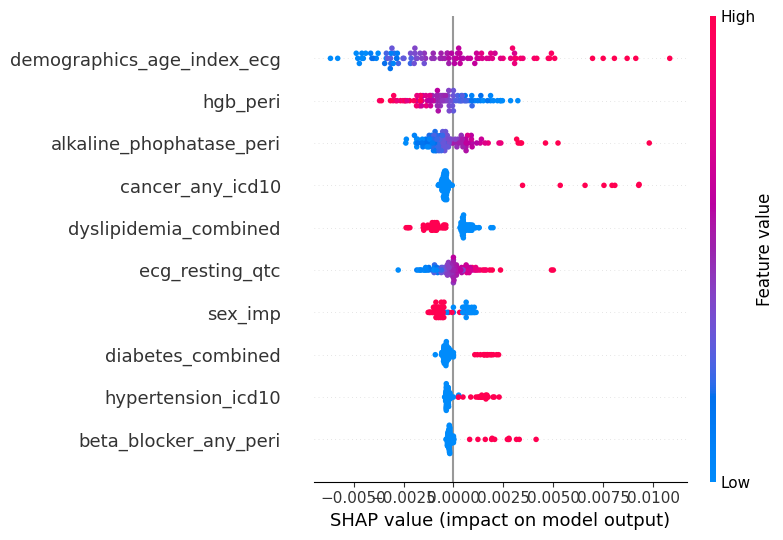

In [5]:
shap.summary_plot(shap_all, X_explain_df, max_display=10, show=False)
plt.tight_layout()
plt.savefig("/home/yu10-shi/global_shap_summary.png", dpi=1000)

from google.colab import files
files.download("global_shap_summary.png")
files.download("global_shap_values.npz")

shap.summary_plot(shap_all, X_explain_df, plot_type="bar", show=False, max_display=10)
plt.tight_layout()
plt.savefig("global_bar_plot.png", dpi=1000)

Model loaded successfully.
Preparing SHAP data...
Computing Gradient SHAP values...
Processing shapes...
Categorical SHAP shape: (300, 61)
Continuous SHAP shape: (300, 17)
Final Combined Shape: (300, 78)
Generating Summary Plot...


/tmp/ipykernel_173/4055404824.py:293: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_all_deep, X_explain_df_ordered, max_display=15, show=False)


Generating Bar Plot...
Done! Files saved.


/tmp/ipykernel_173/4055404824.py:299: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_all_deep, X_explain_df_ordered, plot_type="bar", max_display=15, show=False)


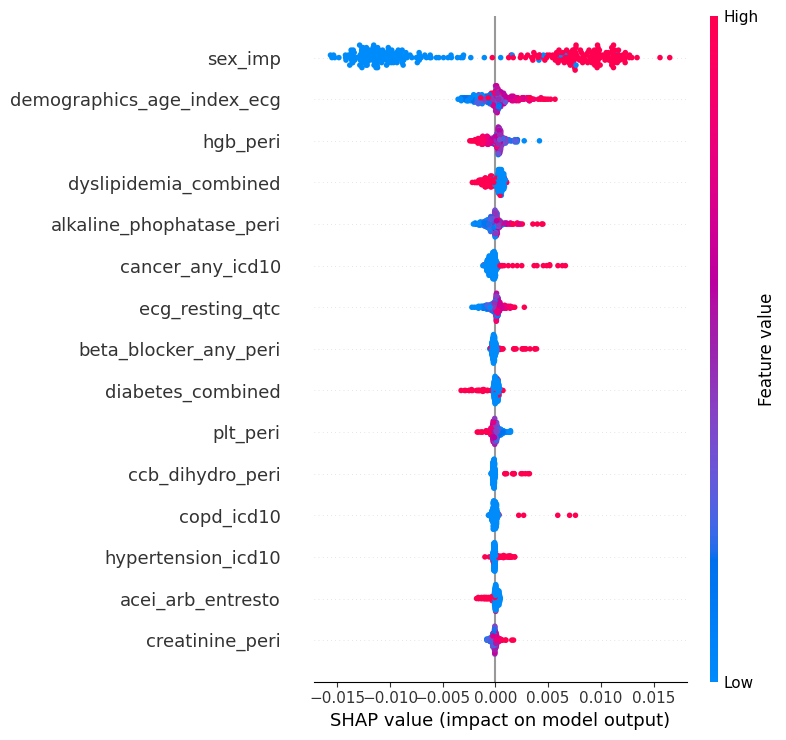

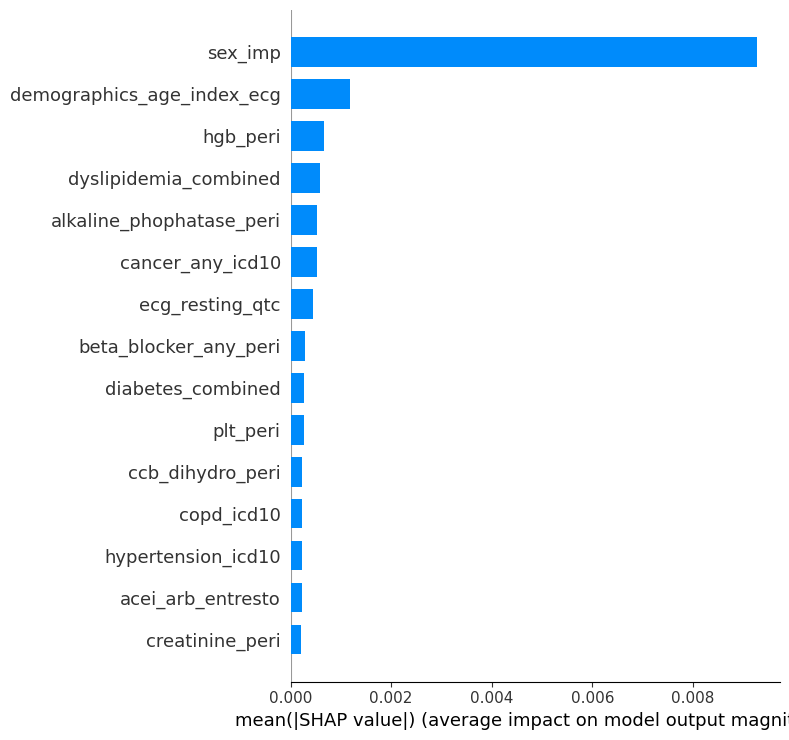

In [10]:
## SHAP deep version
#!pip install pycox torchtuples einops tab-transformer-pytorch shap
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from einops import rearrange, repeat
from torch.serialization import add_safe_globals
import tab_transformer_pytorch
from tab_transformer_pytorch.tab_transformer_pytorch import (
    Transformer as InnerTransformer,
    PreNorm as InnerPreNorm,
    Attention as InnerAttention,
    FeedForward as InnerFeedForward,
    GEGLU as InnerGEGLU,
    MLP as InnerMLP,
)

# ==========================================
# 1. SETUP & DATA LOADING 
# ==========================================

os.chdir('/home/UT_shared/data/')

df_train = pd.read_csv("train.csv")
df_val = pd.read_csv("val.csv")
df_test = pd.read_csv("test.csv")

# Feature Indices
categ_idx = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,
    17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
    31, 32, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,
    60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
    74, 79, 75, 76
]
cont_idx = [
    0, 33, 34, 35, 36,
    48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59
]

# Prepare Test Data
x_cat_test = torch.tensor(df_test.iloc[:, categ_idx].to_numpy(), dtype=torch.long)
x_cont_test = torch.tensor(df_test.iloc[:, cont_idx].to_numpy(), dtype=torch.float32)

feature_names = df_test.columns[categ_idx + cont_idx].tolist()
X_all = df_test.iloc[:, categ_idx + cont_idx].to_numpy()

# Categories for TabTransformer
categories = [int(df_train.iloc[:, idx].max()) + 1 for idx in categ_idx]

# ==========================================
# 2. MODEL DEFINITION (Your Original Code)
# ==========================================

import torchtuples as tt

def exists(val):
    return val is not None
    
class TabTransformerwithEmbedding(tab_transformer_pytorch.TabTransformer):
    def forward(self, x_categ, x_cont, return_attn=False, return_embedding=False):
        xs = []
        assert x_categ.shape[-1] == self.num_categories
        if self.num_unique_categories > 0:
            x_categ = x_categ + self.categories_offset
            categ_embed = self.category_embed(x_categ)
            if self.use_shared_categ_embed:
                shared_categ_embed = repeat(
                    self.shared_category_embed, 
                    'n d -> b n d', 
                    b=categ_embed.shape[0]
                )
                categ_embed = torch.cat((categ_embed, shared_categ_embed), dim=-1)
            x, attns = self.transformer(categ_embed, return_attn=True)
            flat_categ = rearrange(x, 'b ... -> b (...)')
            xs.append(flat_categ)
        if self.num_continuous > 0:
            if exists(getattr(self, 'continuous_mean_std', None)):
                mean, std = self.continuous_mean_std.unbind(dim=-1)
                x_cont = (x_cont - mean) / std
            normed_cont = self.norm(x_cont)
            xs.append(normed_cont)
        x = torch.cat(xs, dim=-1)
        x = self.embedding_proj(x)
        if return_embedding:
            if return_attn:
                return x, attns
            return x
        logits = self.mlp(x)
        if return_attn:
            return logits, attns
        return logits

class TabTransformerSharedCauseSpecificNet(nn.Module):
    def __init__(self, tab_net, embed_dim, num_nodes_shared, num_nodes_indiv,
                 num_risks, out_features, dropout=0.1):
        super().__init__()
        self.tab = TabTransformerwithEmbedding(**tab_net)
        self.shared_mlp = tt.practical.MLPVanilla(
            embed_dim,
            num_nodes_shared[:-1],
            num_nodes_shared[-1],
            batch_norm=True,
            dropout=dropout
        )
        self.risk_nets = nn.ModuleList([
            tt.practical.MLPVanilla(
                num_nodes_shared[-1],
                num_nodes_indiv,
                out_features,
                batch_norm=True,
                dropout=dropout
            )
            for _ in range(num_risks)
        ])

    def forward(self, x_cat, x_cont):
        x_embed = self.tab(x_cat, x_cont, return_embedding=True)
        shared_out = self.shared_mlp(x_embed)
        out = [risk_net(shared_out) for risk_net in self.risk_nets]
        return torch.stack(out, dim=1)

# TabTransformer Internals Hack
setattr(tab_transformer_pytorch, "Transformer", InnerTransformer)
setattr(tab_transformer_pytorch, "PreNorm", InnerPreNorm)
setattr(tab_transformer_pytorch, "Attention", InnerAttention)
setattr(tab_transformer_pytorch, "FeedForward", InnerFeedForward)
setattr(tab_transformer_pytorch, "GEGLU", InnerGEGLU)
setattr(tab_transformer_pytorch, "MLP", InnerMLP)

# ==========================================
# 3. LOAD MODEL
# ==========================================

add_safe_globals([TabTransformerwithEmbedding, TabTransformerSharedCauseSpecificNet])
model_path = "/home/UT_shared/final_model/end-lr0.0001-wd0.01-eta0.8-alpha0.2-bs256-drop0.1-epochs100-dur30-embed500.pt"
net = torch.load(model_path, map_location='cpu', weights_only=False)
net.eval()
print("Model loaded successfully.")

# ==========================================
# 4. DEEP SHAP SETUP (New Code)
# ==========================================

# --- Wrapper to handle Embeddings directly ---
class DeepShapWrapper(nn.Module):
    def __init__(self, original_model, time_idx):
        super().__init__()
        self.net = original_model
        self.tab = original_model.tab
        self.time_idx = time_idx 

    def forward(self, x_cat_embed, x_cont):
        # 1. Handle Shared Embeddings (Replicating TabTransformer logic)
        if self.tab.use_shared_categ_embed:
            shared_categ_embed = repeat(
                self.tab.shared_category_embed,
                'n d -> b n d',
                b=x_cat_embed.shape[0]
            )
            x_cat_embed = torch.cat((x_cat_embed, shared_categ_embed), dim=-1)

        # 2. Transformer Logic
        x, _ = self.tab.transformer(x_cat_embed, return_attn=True)
        flat_categ = rearrange(x, 'b ... -> b (...)')
        
        # 3. Continuous Logic (Manual Normalization)
        xs = [flat_categ]
        if self.tab.num_continuous > 0:
            if exists(getattr(self.tab, 'continuous_mean_std', None)):
                mean, std = self.tab.continuous_mean_std.unbind(dim=-1)
                x_cont = (x_cont - mean) / std
            normed_cont = self.tab.norm(x_cont)
            xs.append(normed_cont)

        # 4. Feed Forward
        x = torch.cat(xs, dim=-1)
        x_embed = self.tab.embedding_proj(x)
        shared_out = self.net.shared_mlp(x_embed)
        
        # 5. Output for specific time index
        out = [risk_net(shared_out) for risk_net in self.net.risk_nets]
        stacked_out = torch.stack(out, dim=1)
        prob = F.softmax(stacked_out, dim=2)
        
        # Return only the target probability (Risk of Event)
        # Shape must be (Batch, 1)
        return prob[:, 0, self.time_idx].unsqueeze(-1) 

# --- Helper to Prepare Embeddings ---
def get_model_inputs(row_indices, data_matrix, model):
    x_cat_raw = torch.tensor(data_matrix[row_indices, :len(categ_idx)]).long()
    x_cont_raw = torch.tensor(data_matrix[row_indices, len(categ_idx):]).float()
    
    with torch.no_grad():
        if model.tab.num_unique_categories > 0:
            x_cat_raw = x_cat_raw + model.tab.categories_offset
            embeddings = model.tab.category_embed(x_cat_raw)
        else:
            embeddings = x_cat_raw 
            
    embeddings.requires_grad = True
    x_cont_raw.requires_grad = True
    return embeddings, x_cont_raw

# ==========================================
# 5. RUNNING SHAP (Using GradientExplainer)
# ==========================================

print("Preparing SHAP data...")
# GradientExplainer is slightly slower per sample, so we adjust numbers if needed.
# 100 background samples is usually sufficient for Expected Gradients.
n_background = 500
n_explain = 300 

bg_idx = np.random.choice(X_all.shape[0], n_background, replace=False)
exp_idx = np.random.choice(X_all.shape[0], n_explain, replace=False)

# Get Embeddings (using the helper from before)
bg_cat_embed, bg_cont = get_model_inputs(bg_idx, X_all, net)
exp_cat_embed, exp_cont = get_model_inputs(exp_idx, X_all, net)

# Initialize Wrapper
t_idx = 20 
model_wrapper = DeepShapWrapper(net, time_idx=t_idx)
model_wrapper.eval()

# --- SWITCH TO GRADIENT EXPLAINER ---
# This uses standard autograd and avoids the "Tensor Size Mismatch" error
explainer = shap.GradientExplainer(model_wrapper, [bg_cat_embed, bg_cont])

print("Computing Gradient SHAP values...")
# nsamples determines how many background samples are used per explanation.
# nsamples=100 is a good balance of speed vs accuracy.
shap_values_raw = explainer.shap_values(
    [exp_cat_embed, exp_cont], 
    nsamples=200
)

# ==========================================
# 6. PROCESSING & PLOTTING 
# ==========================================

# shap_values_raw is a list: [Categorical_Tensor, Continuous_Tensor]
# Each item has shape: (Batch, Features, [Embedding_Dim], Output_Dim)

print("Processing shapes...")

# 1. Handle Categorical Features (Index 0)
# Shape is likely: (Batch, Num_Cats, Embed_Dim, 1)
# We need to:
#   a. Remove the last dimension (Output_Dim = 1)
#   b. Sum over the Embedding dimension to get 1 score per Category
cat_shap = np.array(shap_values_raw[0])
if cat_shap.ndim == 4:
    # Squeeze the last dim (Output Class) -> (Batch, Num_Cats, Embed_Dim)
    cat_shap = cat_shap.squeeze(-1)
    
# Now sum over the embedding dimension (last remaining dim)
sv_cat = np.sum(cat_shap, axis=-1) 
print(f"Categorical SHAP shape: {sv_cat.shape}") # Should be (Batch, Num_Cats)

# 2. Handle Continuous Features (Index 1)
# Shape is likely: (Batch, Num_Cont, 1)
cont_shap = np.array(shap_values_raw[1])
if cont_shap.ndim == 3:
    # Squeeze the last dim (Output Class) -> (Batch, Num_Cont)
    sv_cont = cont_shap.squeeze(-1)
else:
    sv_cont = cont_shap
print(f"Continuous SHAP shape: {sv_cont.shape}") # Should be (Batch, Num_Cont)

# 3. Concatenate
# Now both are 2D: (Batch, Features)
shap_all_deep = np.concatenate([sv_cat, sv_cont], axis=1)
print(f"Final Combined Shape: {shap_all_deep.shape}")

# 4. Create DataFrame
feature_names_ordered = df_test.columns[categ_idx].tolist() + df_test.columns[cont_idx].tolist()
X_explain_df_ordered = pd.DataFrame(
    np.concatenate([X_all[exp_idx, :len(categ_idx)], X_all[exp_idx, len(categ_idx):]], axis=1),
    columns=feature_names_ordered
)

# 5. Plotting
print("Generating Summary Plot...")
plt.figure()
shap.summary_plot(shap_all_deep, X_explain_df_ordered, max_display=15, show=False)
plt.tight_layout()
plt.savefig("/home/yu10-shi/gradient_shap_summary.png", dpi=300)

print("Generating Bar Plot...")
plt.figure()
shap.summary_plot(shap_all_deep, X_explain_df_ordered, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.savefig("/home/yu10-shi/gradient_shap_bar.png", dpi=300)

print("Done! Files saved.")

Loading Data...
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74]
[0, 33, 34, 35, 36, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
Updated categorical idx: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 79, 75, 76]
Idx only in original (removed): []
Idx only in updated (added): [75, 76, 79]
Loading Model...
Calculating Baseline Predictions...
Permuting Categorical Features...
Permuting Continuous Features...
Generating Plots...
Done! Plot saved to /home/yu10-shi/permutation_importance_plot.png

Top 10 Features (Copy for Table 1):
                       Feature  Importance
58                     sex_imp    0.011431
2        dyslipidemia_co

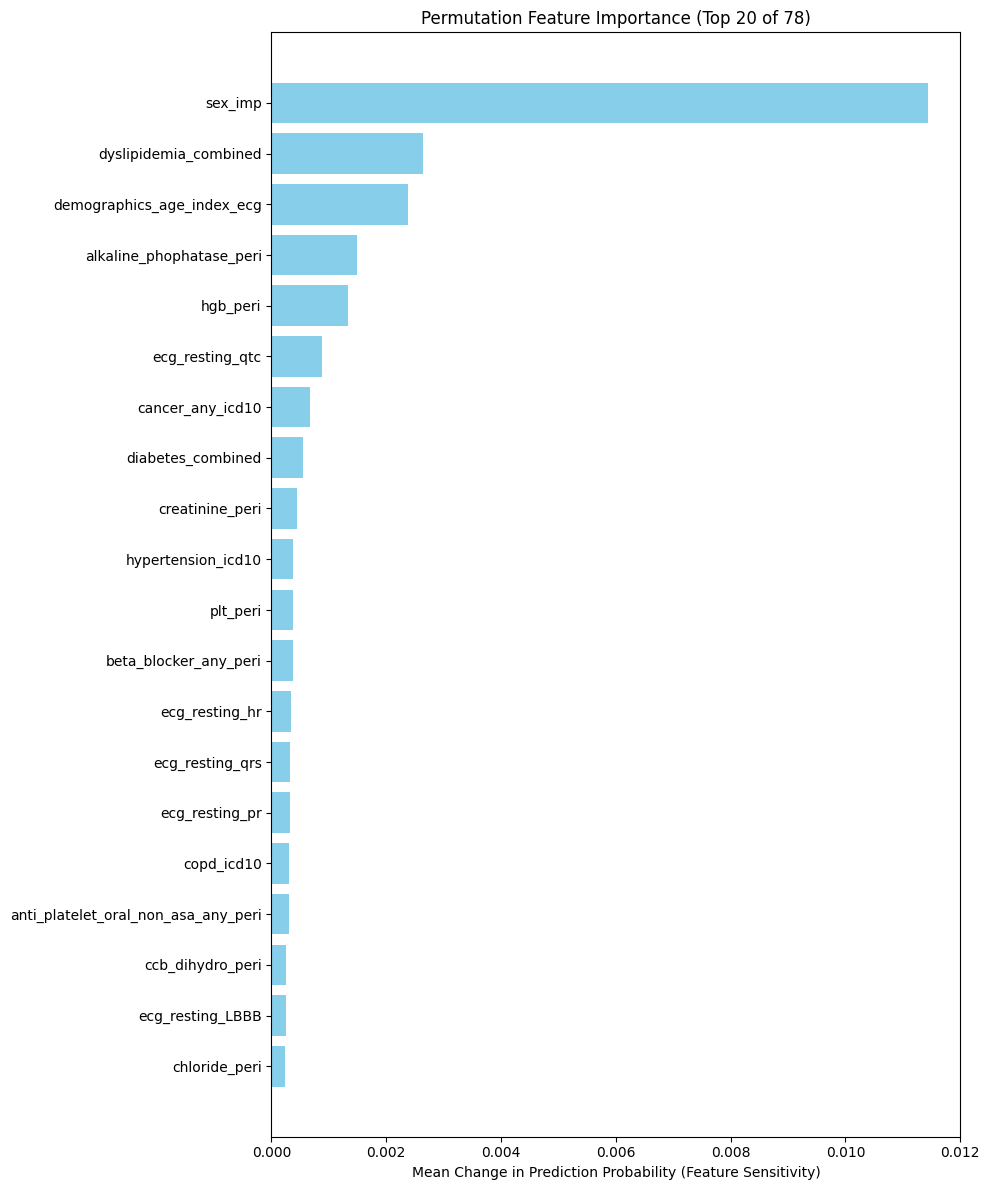

In [1]:
# Permutation + SHAP
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy
from einops import rearrange, repeat
from torch.serialization import add_safe_globals
import tab_transformer_pytorch
from tab_transformer_pytorch.tab_transformer_pytorch import (
    Transformer as InnerTransformer,
    PreNorm as InnerPreNorm,
    Attention as InnerAttention,
    FeedForward as InnerFeedForward,
    GEGLU as InnerGEGLU,
    MLP as InnerMLP,
)
import torchtuples as tt

# ==========================================
# 1. MODEL CLASS DEFINITIONS (REQUIRED FOR LOADING)
# ==========================================

def exists(val):
    return val is not None

class TabTransformerwithEmbedding(tab_transformer_pytorch.TabTransformer):
    def forward(self, x_categ, x_cont, return_attn=False, return_embedding=False):
        xs = []
        assert x_categ.shape[-1] == self.num_categories
        if self.num_unique_categories > 0:
            x_categ = x_categ + self.categories_offset
            categ_embed = self.category_embed(x_categ)
            if self.use_shared_categ_embed:
                shared_categ_embed = repeat(
                    self.shared_category_embed, 
                    'n d -> b n d', 
                    b=categ_embed.shape[0]
                )
                categ_embed = torch.cat((categ_embed, shared_categ_embed), dim=-1)
            x, attns = self.transformer(categ_embed, return_attn=True)
            flat_categ = rearrange(x, 'b ... -> b (...)')
            xs.append(flat_categ)
        if self.num_continuous > 0:
            if exists(getattr(self, 'continuous_mean_std', None)):
                mean, std = self.continuous_mean_std.unbind(dim=-1)
                x_cont = (x_cont - mean) / std
            normed_cont = self.norm(x_cont)
            xs.append(normed_cont)
        x = torch.cat(xs, dim=-1)
        x = self.embedding_proj(x)
        if return_embedding:
            if return_attn:
                return x, attns
            return x
        logits = self.mlp(x)
        if return_attn:
            return logits, attns
        return logits

class TabTransformerSharedCauseSpecificNet(nn.Module):
    def __init__(self, tab_net, embed_dim, num_nodes_shared, num_nodes_indiv,
                 num_risks, out_features, dropout=0.1):
        super().__init__()
        self.tab = TabTransformerwithEmbedding(**tab_net)
        self.shared_mlp = tt.practical.MLPVanilla(
            embed_dim,
            num_nodes_shared[:-1],
            num_nodes_shared[-1],
            batch_norm=True,
            dropout=dropout
        )
        self.risk_nets = nn.ModuleList([
            tt.practical.MLPVanilla(
                num_nodes_shared[-1],
                num_nodes_indiv,
                out_features,
                batch_norm=True,
                dropout=dropout
            )
            for _ in range(num_risks)
        ])

    def forward(self, x_cat, x_cont):
        x_embed = self.tab(x_cat, x_cont, return_embedding=True)
        shared_out = self.shared_mlp(x_embed)
        out = [risk_net(shared_out) for risk_net in self.risk_nets]
        return torch.stack(out, dim=1)

# TabTransformer Internals Hack
setattr(tab_transformer_pytorch, "Transformer", InnerTransformer)
setattr(tab_transformer_pytorch, "PreNorm", InnerPreNorm)
setattr(tab_transformer_pytorch, "Attention", InnerAttention)
setattr(tab_transformer_pytorch, "FeedForward", InnerFeedForward)
setattr(tab_transformer_pytorch, "GEGLU", InnerGEGLU)
setattr(tab_transformer_pytorch, "MLP", InnerMLP)

# ==========================================
# 2. DATA & MODEL LOADING
# ==========================================

os.chdir('/home/UT_shared/data/')
print("Loading Data...")

df_test = pd.read_csv("test.csv")
df = pd.read_csv("/home/UT_shared/data/df_imputed.csv")

# df_train = pd.read_csv("train.csv")

# Feature Indices
# categ_idx = [
#     1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,
#     17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
#     31, 32, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,
#     60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
#     74, 79, 75, 76
# ]
# cont_idx = [
#     0, 33, 34, 35, 36,
#     48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59
# ]
dict_df = pd.read_csv('/home/UHN/Data dictionary_for_UofT_final.csv')
dict_df.loc[15, "Variable name"] = "obstructive._sleep_apnea_icd10"

categ_vars = dict_df.loc[
    dict_df["Variable type"].isin(["boolean", "categorical"]),
    "Variable name"
].tolist()

cont_vars = dict_df.loc[
    dict_df["Variable type"] == "numeric",
    "Variable name"
].tolist()

categ_idx_1 = [df.columns.get_loc(v) for v in categ_vars if v in df.columns]
cont_idx  = [df.columns.get_loc(v) for v in cont_vars if v in df.columns]

print(categ_idx_1)
print(cont_idx)

vars_to_add = ['sex_imp', 'acei_arb_entresto', 'acute_mi_angina_other']

categ_idx = categ_idx_1.copy()

for v in vars_to_add:
    if v in df.columns:
        idx = df.columns.get_loc(v)
        if idx not in categ_idx:   # avoid duplicates
            categ_idx.append(idx)

print("Updated categorical idx:", categ_idx)

only_in_old = sorted(set(categ_idx_1) - set(categ_idx))  
only_in_new = sorted(set(categ_idx) - set(categ_idx_1))  

print("Idx only in original (removed):", only_in_old)
print("Idx only in updated (added):", only_in_new)

all_used_idx = set(cont_idx) | set(categ_idx)
other_idx = [i for i in range(len(df.columns)) if i not in all_used_idx]
other_vars = df.columns[other_idx].tolist()


feature_names_ordered = df_test.columns[categ_idx].tolist() + df_test.columns[cont_idx].tolist()
X_all = df_test.iloc[:, categ_idx + cont_idx].to_numpy()

# Load Model
print("Loading Model...")
add_safe_globals([TabTransformerwithEmbedding, TabTransformerSharedCauseSpecificNet])
model_path = "/home/UT_shared/final_model/end-lr0.0001-wd0.01-eta0.8-alpha0.2-bs256-drop0.1-epochs100-dur30-embed500.pt"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = torch.load(model_path, map_location=device, weights_only=False)
net.eval()
net.to(device)

# ==========================================
# 3. PERMUTATION IMPORTANCE LOGIC
# ==========================================

# Use a subset for speed (Permutation is slow on large data)
n_samples = 3000 
indices = np.random.choice(len(df_test), n_samples, replace=False)

# Prepare Baseline NumPy Arrays
x_cat_baseline = df_test.iloc[indices, categ_idx].to_numpy()
x_cont_baseline = df_test.iloc[indices, cont_idx].to_numpy()

def get_preds(cat_np, cont_np, model, time_idx=0):
    """ Helper: Runs model inference on numpy arrays """
    with torch.no_grad():
        x_cat = torch.tensor(cat_np, dtype=torch.long).to(device)
        x_cont = torch.tensor(cont_np, dtype=torch.float32).to(device)
        
        preds = model(x_cat, x_cont)
        prob = F.softmax(preds, dim=2)
        return prob[:, 0, time_idx].cpu().numpy() # Return Risk Probability

# 1. Get Baseline Predictions
print("Calculating Baseline Predictions...")
base_preds = get_preds(x_cat_baseline, x_cont_baseline, net)

feature_importance = {}

# 2. Iterate Categorical Features
print("Permuting Categorical Features...")
cat_names = df_test.columns[categ_idx]
for i, name in enumerate(cat_names):
    # Copy baseline
    x_cat_shuffled = x_cat_baseline.copy()
    # Shuffle only column 'i'
    np.random.shuffle(x_cat_shuffled[:, i])
    
    # Predict
    new_preds = get_preds(x_cat_shuffled, x_cont_baseline, net)
    
    # Metric: Mean Absolute Difference (Sensitivity)
    importance = np.mean(np.abs(new_preds - base_preds))
    feature_importance[name] = importance
    # Optional: Print progress
    # print(f"{name}: {importance:.5f}")

# 3. Iterate Continuous Features
print("Permuting Continuous Features...")
cont_names = df_test.columns[cont_idx]
for i, name in enumerate(cont_names):
    # Copy baseline
    x_cont_shuffled = x_cont_baseline.copy()
    # Shuffle only column 'i'
    np.random.shuffle(x_cont_shuffled[:, i])
    
    # Predict
    new_preds = get_preds(x_cat_baseline, x_cont_shuffled, net)
    
    # Metric
    importance = np.mean(np.abs(new_preds - base_preds))
    feature_importance[name] = importance

# ==========================================
# 4. RESULTS & PLOTTING
# ==========================================

print("Generating Plots...")
# Convert to DataFrame
imp_df = pd.DataFrame(list(feature_importance.items()), columns=['Feature', 'Importance'])
imp_df = imp_df.sort_values(by='Importance', ascending=True) # Ascending for correct bar plot order

# Save raw numbers
imp_df.to_csv("/home/yu10-shi/permutation_importance_values.csv", index=False)

# Plot Top 20
top_df = imp_df.tail(20)

plt.figure(figsize=(10, 12))
plt.barh(top_df['Feature'], top_df['Importance'], color='skyblue')
plt.xlabel("Mean Change in Prediction Probability (Feature Sensitivity)")
plt.title(f"Permutation Feature Importance (Top 20 of {len(feature_importance)})")
plt.tight_layout()
plt.savefig("/home/yu10-shi/permutation_importance_plot.png", dpi=300)

print("Done! Plot saved to /home/yu10-shi/permutation_importance_plot.png")

# ==========================================
# Print Top 10 for your Table 1
# ==========================================
print("\nTop 10 Features (Copy for Table 1):")
print(imp_df.tail(10).sort_values(by='Importance', ascending=False))

Top 10 Features by Permutation: ['sex_imp', 'dyslipidemia_combined', 'demographics_age_index_ecg', 'hgb_peri', 'alkaline_phophatase_peri', 'ecg_resting_qtc', 'cancer_any_icd10', 'diabetes_combined', 'beta_blocker_any_peri', 'creatinine_peri']
Plot saved.


/tmp/ipykernel_92/412162071.py:136: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


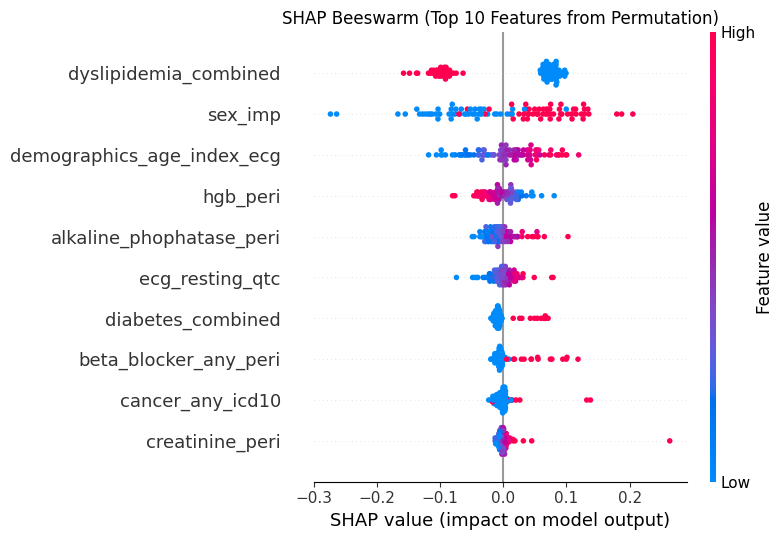

In [10]:
#!pip install shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

# ==========================================
# 1. GET TOP FEATURES FROM PERMUTATION
# ==========================================
# Assuming 'imp_df' comes from the Permutation code I provided earlier
# imp_df columns: ['Feature', 'Importance']

# Sort by importance and take Top 10
top_10_features = imp_df.sort_values(by='Importance', ascending=False).head(10)['Feature'].tolist()

print(f"Top 10 Features by Permutation: {top_10_features}")

# ==========================================
# 2. FILTER SHAP DATA TO MATCH
# ==========================================
# We need to find the indices of these 10 features in the SHAP matrix
class DeepShapWrapper(nn.Module):
    def __init__(self, original_model, time_idx):
        super().__init__()
        self.net = original_model
        self.tab = original_model.tab
        self.time_idx = time_idx 

    def forward(self, x_cat_embed, x_cont):
        # 1. Handle Shared Embeddings (Replicating TabTransformer logic)
        if self.tab.use_shared_categ_embed:
            shared_categ_embed = repeat(
                self.tab.shared_category_embed,
                'n d -> b n d',
                b=x_cat_embed.shape[0]
            )
            x_cat_embed = torch.cat((x_cat_embed, shared_categ_embed), dim=-1)

        # 2. Transformer Logic
        x, _ = self.tab.transformer(x_cat_embed, return_attn=True)
        flat_categ = rearrange(x, 'b ... -> b (...)')
        
        # 3. Continuous Logic (Manual Normalization)
        xs = [flat_categ]
        if self.tab.num_continuous > 0:
            if exists(getattr(self.tab, 'continuous_mean_std', None)):
                mean, std = self.tab.continuous_mean_std.unbind(dim=-1)
                x_cont = (x_cont - mean) / std
            normed_cont = self.tab.norm(x_cont)
            xs.append(normed_cont)

        # 4. Feed Forward
        x = torch.cat(xs, dim=-1)
        x_embed = self.tab.embedding_proj(x)
        shared_out = self.net.shared_mlp(x_embed)
        
        # 5. Output for specific time index
        out = [risk_net(shared_out) for risk_net in self.net.risk_nets]
        stacked_out = torch.stack(out, dim=1)
        prob = F.softmax(stacked_out, dim=2)
        
        # Return only the target probability (Risk of Event)
        # Shape must be (Batch, 1)
        #return prob[:, 0, self.time_idx].unsqueeze(-1)
        return stacked_out[:, 0, self.time_idx].unsqueeze(-1)

def get_model_inputs(row_indices, data_matrix, model):
    device = next(model.parameters()).device
    x_cat_raw = torch.tensor(data_matrix[row_indices, :len(categ_idx)]).long().to(device)
    x_cont_raw = torch.tensor(data_matrix[row_indices, len(categ_idx):]).float().to(device)
    
    with torch.no_grad():
        if model.tab.num_unique_categories > 0:
            x_cat_raw = x_cat_raw + model.tab.categories_offset
            embeddings = model.tab.category_embed(x_cat_raw)
        else:
            embeddings = x_cat_raw 
            
    embeddings.requires_grad = True
    x_cont_raw.requires_grad = True
    return embeddings, x_cont_raw

n_bg, n_exp = 200, 100 # Adjust based on speed needs
bg_idx = np.random.choice(X_all.shape[0], n_bg, replace=False)
exp_idx = np.random.choice(X_all.shape[0], n_exp, replace=False)

# Get raw inputs for the explainer
bg_cat_embed, bg_cont = get_model_inputs(bg_idx, X_all, net)
exp_cat_embed, exp_cont = get_model_inputs(exp_idx, X_all, net)

# 3. Initialize and Run Explainer
model_wrapper = DeepShapWrapper(net, time_idx=0).eval().to(device)
explainer = shap.GradientExplainer(model_wrapper, [bg_cat_embed, bg_cont])
shap_values_raw = explainer.shap_values([exp_cat_embed, exp_cont], nsamples=100)

# 4. PROCESS INTO 'shap_all_deep'
# Process Categorical: Sum across embedding dimension
cat_shap = np.array(shap_values_raw[0]).squeeze(-1)
sv_cat = np.sum(cat_shap, axis=-1) 

# Process Continuous
sv_cont = np.array(shap_values_raw[1]).squeeze(-1)

# Combined Matrix
shap_all_deep = np.concatenate([sv_cat, sv_cont], axis=1)

# 5. PROCESS INTO 'X_explain_df_ordered'
# This is the original feature values for the records we explained
X_explain_df_ordered = pd.DataFrame(
    np.concatenate([X_all[exp_idx, :len(categ_idx)], X_all[exp_idx, len(categ_idx):]], axis=1),
    columns=feature_names_ordered
)

# Get the list of all feature names used in SHAP
# (Must match the order of columns in X_explain_df_ordered)
all_shap_cols = X_explain_df_ordered.columns.tolist()

# Find indices for the Top 10
top_10_indices = [all_shap_cols.index(feat) for feat in top_10_features]

# Filter the SHAP values matrix
# shap_all_deep shape: (Samples, Total_Features) -> (Samples, 10)
shap_subset = shap_all_deep[:, top_10_indices]

# Filter the Input Data DataFrame
X_subset_df = X_explain_df_ordered[top_10_features]

# ==========================================
# 3. GENERATE THE CONSISTENT PLOT
# ==========================================

plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm (Top 10 Features from Permutation)")

# plot_type="dot" is the standard beeswarm
shap.summary_plot(
    shap_subset, 
    X_subset_df, 
    plot_type="dot", 
    max_display=10, 
    show=False
)

plt.tight_layout()
print("Plot saved.")

In [6]:
### SHAP by age
#!pip install shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap
import os

# ==========================================
# 1. GET TOP FEATURES FROM PERMUTATION
# ==========================================
top_10_features = (
    imp_df.sort_values(by='Importance', ascending=False)
    .head(10)['Feature']
    .tolist()
)

print(f"Top 10 Features by Permutation: {top_10_features}")

# ==========================================
# 2. SHAP WRAPPER
# ==========================================
class DeepShapWrapper(nn.Module):
    def __init__(self, original_model, time_idx):
        super().__init__()
        self.net = original_model
        self.tab = original_model.tab
        self.time_idx = time_idx

    def forward(self, x_cat_embed, x_cont):
        if self.tab.use_shared_categ_embed:
            shared_categ_embed = repeat(
                self.tab.shared_category_embed,
                'n d -> b n d',
                b=x_cat_embed.shape[0]
            )
            x_cat_embed = torch.cat((x_cat_embed, shared_categ_embed), dim=-1)

        x, _ = self.tab.transformer(x_cat_embed, return_attn=True)
        flat_categ = rearrange(x, 'b ... -> b (...)')

        xs = [flat_categ]
        if self.tab.num_continuous > 0:
            if exists(getattr(self.tab, 'continuous_mean_std', None)):
                mean, std = self.tab.continuous_mean_std.unbind(dim=-1)
                x_cont = (x_cont - mean) / std
            normed_cont = self.tab.norm(x_cont)
            xs.append(normed_cont)

        x = torch.cat(xs, dim=-1)
        x_embed = self.tab.embedding_proj(x)
        shared_out = self.net.shared_mlp(x_embed)

        out = [risk_net(shared_out) for risk_net in self.net.risk_nets]
        stacked_out = torch.stack(out, dim=1)

        # return logit at selected risk/time
        return stacked_out[:, 0, self.time_idx].unsqueeze(-1)

def get_model_inputs(row_indices, data_matrix, model):
    device = next(model.parameters()).device

    x_cat_raw = torch.tensor(
        data_matrix[row_indices, :len(categ_idx)],
        dtype=torch.long,
        device=device
    )
    x_cont_raw = torch.tensor(
        data_matrix[row_indices, len(categ_idx):],
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():
        if model.tab.num_unique_categories > 0:
            x_cat_raw = x_cat_raw + model.tab.categories_offset
            embeddings = model.tab.category_embed(x_cat_raw)
        else:
            embeddings = x_cat_raw

    embeddings.requires_grad = True
    x_cont_raw.requires_grad = True
    return embeddings, x_cont_raw

# ==========================================
# 3. RUN SHAP
# ==========================================
n_bg, n_exp = 200, 100
bg_idx = np.random.choice(X_all.shape[0], n_bg, replace=False)
exp_idx = np.random.choice(X_all.shape[0], n_exp, replace=False)

bg_cat_embed, bg_cont = get_model_inputs(bg_idx, X_all, net)
exp_cat_embed, exp_cont = get_model_inputs(exp_idx, X_all, net)

model_wrapper = DeepShapWrapper(net, time_idx=0).eval().to(device)
explainer = shap.GradientExplainer(model_wrapper, [bg_cat_embed, bg_cont])
shap_values_raw = explainer.shap_values([exp_cat_embed, exp_cont], nsamples=100)

# ==========================================
# 4. PROCESS SHAP VALUES
# ==========================================
# categorical: sum over embedding dimension
cat_shap = np.array(shap_values_raw[0]).squeeze(-1)
sv_cat = np.sum(cat_shap, axis=-1)

# continuous
sv_cont = np.array(shap_values_raw[1]).squeeze(-1)

# combined SHAP matrix
shap_all_deep = np.concatenate([sv_cat, sv_cont], axis=1)

# original feature values for explained records
X_explain_df_ordered = pd.DataFrame(
    np.concatenate(
        [
            X_all[exp_idx, :len(categ_idx)],
            X_all[exp_idx, len(categ_idx):]
        ],
        axis=1
    ),
    columns=feature_names_ordered
)

all_shap_cols = X_explain_df_ordered.columns.tolist()
top_10_indices = [all_shap_cols.index(feat) for feat in top_10_features]

shap_subset = shap_all_deep[:, top_10_indices]
X_subset_df = X_explain_df_ordered[top_10_features].copy()

# ==========================================
# 5. SPLIT BY AGE
# ==========================================
age_col = "demographics_age_index_ecg"   

if age_col not in X_explain_df_ordered.columns:
    raise ValueError(
        f"Column '{age_col}' not found in X_explain_df_ordered. "
        f"Available columns include: {X_explain_df_ordered.columns.tolist()[:20]} ..."
    )

age_values = pd.to_numeric(X_explain_df_ordered[age_col], errors="coerce")

mask_age_gt_65 = age_values > 65
mask_age_lt_65 = age_values < 65

print(f"Number of explained samples with age > 65: {mask_age_gt_65.sum()}")
print(f"Number of explained samples with age < 65: {mask_age_lt_65.sum()}")

# optional: if you want to include age == 65 in one group, change masks accordingly

# ==========================================
# 6. GENERATE TWO SHAP PLOTS
# ==========================================
out_dir = "/home/yu10-shi"
os.makedirs(out_dir, exist_ok=True)

def save_shap_beeswarm(shap_vals, feature_df, title, save_path):
    if shap_vals.shape[0] == 0:
        print(f"Skipping plot because no samples are available: {title}")
        return

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_vals,
        feature_df,
        plot_type="dot",
        max_display=10,
        show=False
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {save_path}")

# age > 65
save_shap_beeswarm(
    shap_subset[mask_age_gt_65.values, :],
    X_subset_df.loc[mask_age_gt_65.values, :],
    "SHAP Beeswarm (Top 10 Features, Age > 65)",
    os.path.join(out_dir, "shap_beeswarm_top10_age_gt65.png")
)

# age < 65
save_shap_beeswarm(
    shap_subset[mask_age_lt_65.values, :],
    X_subset_df.loc[mask_age_lt_65.values, :],
    "SHAP Beeswarm (Top 10 Features, Age < 65)",
    os.path.join(out_dir, "shap_beeswarm_top10_age_lt65.png")
)

# ==========================================
# 7. OPTIONAL: SAVE THE SUBGROUP TABLES
# ==========================================
X_subset_df.loc[mask_age_gt_65.values, :].to_csv(
    os.path.join(out_dir, "shap_inputs_top10_age_gt65.csv"),
    index=False
)
X_subset_df.loc[mask_age_lt_65.values, :].to_csv(
    os.path.join(out_dir, "shap_inputs_top10_age_lt65.csv"),
    index=False
)

pd.DataFrame(
    shap_subset[mask_age_gt_65.values, :],
    columns=top_10_features
).to_csv(
    os.path.join(out_dir, "shap_values_top10_age_gt65.csv"),
    index=False
)

pd.DataFrame(
    shap_subset[mask_age_lt_65.values, :],
    columns=top_10_features
).to_csv(
    os.path.join(out_dir, "shap_values_top10_age_lt65.csv"),
    index=False
)

print("Finished generating subgroup SHAP plots.")

Top 10 Features by Permutation: ['sex_imp', 'dyslipidemia_combined', 'demographics_age_index_ecg', 'alkaline_phophatase_peri', 'hgb_peri', 'ecg_resting_qtc', 'cancer_any_icd10', 'diabetes_combined', 'creatinine_peri', 'beta_blocker_any_peri']
Number of explained samples with age > 65: 27
Number of explained samples with age < 65: 71
Saved: /home/yu10-shi/shap_beeswarm_top10_age_gt65.png


/tmp/ipykernel_240/2283258212.py:163: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_240/2283258212.py:163: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved: /home/yu10-shi/shap_beeswarm_top10_age_lt65.png
Finished generating subgroup SHAP plots.


In [2]:
########### Use Kernel Function ###########
#!pip install shap
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchtuples as tt

from einops import rearrange, repeat
from torch.serialization import add_safe_globals

import tab_transformer_pytorch
from tab_transformer_pytorch.tab_transformer_pytorch import (
    Transformer as InnerTransformer,
    PreNorm as InnerPreNorm,
    Attention as InnerAttention,
    FeedForward as InnerFeedForward,
    GEGLU as InnerGEGLU,
    MLP as InnerMLP,
)

# ==========================================
# 0. REPRODUCIBILITY
# ==========================================
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# ==========================================
# 1. MODEL CLASS DEFINITIONS
# ==========================================
def exists(val):
    return val is not None


class TabTransformerwithEmbedding(tab_transformer_pytorch.TabTransformer):
    def forward(self, x_categ, x_cont, return_attn=False, return_embedding=False):
        xs = []
        assert x_categ.shape[-1] == self.num_categories

        if self.num_unique_categories > 0:
            x_categ = x_categ + self.categories_offset
            categ_embed = self.category_embed(x_categ)

            if self.use_shared_categ_embed:
                shared_categ_embed = repeat(
                    self.shared_category_embed,
                    'n d -> b n d',
                    b=categ_embed.shape[0]
                )
                categ_embed = torch.cat((categ_embed, shared_categ_embed), dim=-1)

            x, attns = self.transformer(categ_embed, return_attn=True)
            flat_categ = rearrange(x, 'b ... -> b (...)')
            xs.append(flat_categ)

        if self.num_continuous > 0:
            if exists(getattr(self, 'continuous_mean_std', None)):
                mean, std = self.continuous_mean_std.unbind(dim=-1)
                x_cont = (x_cont - mean) / std
            normed_cont = self.norm(x_cont)
            xs.append(normed_cont)

        x = torch.cat(xs, dim=-1)
        x = self.embedding_proj(x)

        if return_embedding:
            if return_attn:
                return x, attns
            return x

        logits = self.mlp(x)
        if return_attn:
            return logits, attns
        return logits


class TabTransformerSharedCauseSpecificNet(nn.Module):
    def __init__(
        self,
        tab_net,
        embed_dim,
        num_nodes_shared,
        num_nodes_indiv,
        num_risks,
        out_features,
        dropout=0.1
    ):
        super().__init__()
        self.tab = TabTransformerwithEmbedding(**tab_net)

        self.shared_mlp = tt.practical.MLPVanilla(
            embed_dim,
            num_nodes_shared[:-1],
            num_nodes_shared[-1],
            batch_norm=True,
            dropout=dropout
        )

        self.risk_nets = nn.ModuleList([
            tt.practical.MLPVanilla(
                num_nodes_shared[-1],
                num_nodes_indiv,
                out_features,
                batch_norm=True,
                dropout=dropout
            )
            for _ in range(num_risks)
        ])

    def forward(self, x_cat, x_cont):
        x_embed = self.tab(x_cat, x_cont, return_embedding=True)
        shared_out = self.shared_mlp(x_embed)
        out = [risk_net(shared_out) for risk_net in self.risk_nets]
        return torch.stack(out, dim=1)


# ==========================================
# 2. PATCH TABTRANSFORMER INTERNAL SYMBOLS
# ==========================================
setattr(tab_transformer_pytorch, "Transformer", InnerTransformer)
setattr(tab_transformer_pytorch, "PreNorm", InnerPreNorm)
setattr(tab_transformer_pytorch, "Attention", InnerAttention)
setattr(tab_transformer_pytorch, "FeedForward", InnerFeedForward)
setattr(tab_transformer_pytorch, "GEGLU", InnerGEGLU)
setattr(tab_transformer_pytorch, "MLP", InnerMLP)

# ==========================================
# 3. DATA LOADING
# ==========================================
os.chdir('/home/UT_shared/data/')
print("Loading data...")

df_test = pd.read_csv("test.csv")
df = pd.read_csv("/home/UT_shared/data/df_imputed.csv")
dict_df = pd.read_csv('/home/UHN/Data dictionary_for_UofT_final.csv')

# Fix one variable name if needed
dict_df.loc[15, "Variable name"] = "obstructive._sleep_apnea_icd10"

# Variable typing from dictionary
categ_vars = dict_df.loc[
    dict_df["Variable type"].isin(["boolean", "categorical"]),
    "Variable name"
].tolist()

cont_vars = dict_df.loc[
    dict_df["Variable type"] == "numeric",
    "Variable name"
].tolist()

# Indices in df
categ_idx_1 = [df.columns.get_loc(v) for v in categ_vars if v in df.columns]
cont_idx = [df.columns.get_loc(v) for v in cont_vars if v in df.columns]

# Manually add some variables as categorical
vars_to_add = ['sex_imp', 'acei_arb_entresto', 'acute_mi_angina_other']
categ_idx = categ_idx_1.copy()
for v in vars_to_add:
    if v in df.columns:
        idx = df.columns.get_loc(v)
        if idx not in categ_idx:
            categ_idx.append(idx)

# Sanity print
print("Number of categorical features:", len(categ_idx))
print("Number of continuous features:", len(cont_idx))

only_in_old = sorted(set(categ_idx_1) - set(categ_idx))
only_in_new = sorted(set(categ_idx) - set(categ_idx_1))
print("Idx only in original (removed):", only_in_old)
print("Idx only in updated (added):", only_in_new)

all_used_idx = set(cont_idx) | set(categ_idx)
other_idx = [i for i in range(len(df.columns)) if i not in all_used_idx]
other_vars = df.columns[other_idx].tolist()
print("Unused variables:", other_vars)

# IMPORTANT:
# Make sure test.csv has the same column order as the model input order.
feature_names_ordered = df_test.columns[categ_idx].tolist() + df_test.columns[cont_idx].tolist()
X_all = df_test.iloc[:, categ_idx + cont_idx].to_numpy()

# ==========================================
# 4. LOAD MODEL
# ==========================================
print("Loading model...")
add_safe_globals([TabTransformerwithEmbedding, TabTransformerSharedCauseSpecificNet])

model_path = "/home/UT_shared/final_model/end-lr0.0001-wd0.01-eta0.8-alpha0.2-bs256-drop0.1-epochs100-dur30-embed500.pt"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

net = torch.load(model_path, map_location=device, weights_only=False)
net.eval()
net.to(device)

print("Model loaded on:", device)

# ==========================================
# 5. HELPER: MODEL PREDICTION
# ==========================================
def get_preds(cat_np, cont_np, model, time_idx=0, risk_idx=0, return_prob=True):
    """
    cat_np: numpy array of categorical inputs
    cont_np: numpy array of continuous inputs
    return_prob=True: return softmax probability over time bins for given risk/time
    return_prob=False: return raw logit for given risk/time
    """
    with torch.no_grad():
        x_cat = torch.tensor(cat_np, dtype=torch.long, device=device)
        x_cont = torch.tensor(cont_np, dtype=torch.float32, device=device)

        preds = model(x_cat, x_cont)  # [batch, num_risks, out_features]

        if return_prob:
            prob = F.softmax(preds, dim=2)
            return prob[:, risk_idx, time_idx].cpu().numpy()
        else:
            return preds[:, risk_idx, time_idx].cpu().numpy()

# ==========================================
# 6. PERMUTATION IMPORTANCE
# ==========================================
print("Running permutation importance...")

# Settings
time_idx = 0
risk_idx = 0
n_samples_perm = 3000
n_repeats_perm = 5

rng = np.random.default_rng(SEED)
indices = rng.choice(len(df_test), size=min(n_samples_perm, len(df_test)), replace=False)

x_cat_baseline = df_test.iloc[indices, categ_idx].to_numpy()
x_cont_baseline = df_test.iloc[indices, cont_idx].to_numpy()

base_preds = get_preds(
    x_cat_baseline,
    x_cont_baseline,
    net,
    time_idx=time_idx,
    risk_idx=risk_idx,
    return_prob=True
)

feature_importance = {}

# Categorical features
print("Permuting categorical features...")
cat_names = df_test.columns[categ_idx].tolist()

for i, name in enumerate(cat_names):
    scores = []
    for _ in range(n_repeats_perm):
        x_cat_shuffled = x_cat_baseline.copy()
        perm = rng.permutation(x_cat_shuffled.shape[0])
        x_cat_shuffled[:, i] = x_cat_shuffled[perm, i]

        new_preds = get_preds(
            x_cat_shuffled,
            x_cont_baseline,
            net,
            time_idx=time_idx,
            risk_idx=risk_idx,
            return_prob=True
        )
        importance = np.mean(np.abs(new_preds - base_preds))
        scores.append(importance)

    feature_importance[name] = float(np.mean(scores))

# Continuous features
print("Permuting continuous features...")
cont_names = df_test.columns[cont_idx].tolist()

for i, name in enumerate(cont_names):
    scores = []
    for _ in range(n_repeats_perm):
        x_cont_shuffled = x_cont_baseline.copy()
        perm = rng.permutation(x_cont_shuffled.shape[0])
        x_cont_shuffled[:, i] = x_cont_shuffled[perm, i]

        new_preds = get_preds(
            x_cat_baseline,
            x_cont_shuffled,
            net,
            time_idx=time_idx,
            risk_idx=risk_idx,
            return_prob=True
        )
        importance = np.mean(np.abs(new_preds - base_preds))
        scores.append(importance)

    feature_importance[name] = float(np.mean(scores))

# Save permutation results
imp_df = pd.DataFrame(
    list(feature_importance.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)

perm_csv_path = "/home/yu10-shi/permutation_importance_values.csv"
imp_df.to_csv(perm_csv_path, index=False)
print(f"Saved permutation values to: {perm_csv_path}")

# Plot top 20 permutation
top_df = imp_df.tail(20)

plt.figure(figsize=(10, 12))
plt.barh(top_df['Feature'], top_df['Importance'])
plt.xlabel("Mean Absolute Change in Prediction Probability")
plt.title(f"Permutation Feature Importance (Top 20, risk={risk_idx}, time_idx={time_idx})")
plt.tight_layout()
perm_plot_path = "/home/yu10-shi/permutation_importance_plot.png"
plt.savefig(perm_plot_path, dpi=300)
plt.close()
print(f"Saved permutation plot to: {perm_plot_path}")

print("\nTop 10 Features from permutation:")
print(imp_df.tail(10).sort_values(by='Importance', ascending=False))

# ==========================================
# 7. KERNEL SHAP
# ==========================================
print("Running Kernel SHAP...")

top_10_features = (
    imp_df.sort_values(by='Importance', ascending=False)
    .head(10)['Feature']
    .tolist()
)
print("Top 10 features by permutation:", top_10_features)

def predict_prob_at_time_idx_kernel(time_idx=0, risk_idx=0, return_prob=True):
    """
    Returns a function that accepts a combined numpy matrix:
    [categorical columns first | continuous columns second]
    """
    def fn(x_combined_numpy):
        with torch.no_grad():
            n_cat = len(categ_idx)

            x_cat = torch.tensor(
                x_combined_numpy[:, :n_cat],
                dtype=torch.long,
                device=device
            )
            x_cont = torch.tensor(
                x_combined_numpy[:, n_cat:],
                dtype=torch.float32,
                device=device
            )

            preds = net(x_cat, x_cont)

            if return_prob:
                prob = F.softmax(preds, dim=2)
                return prob[:, risk_idx, time_idx].cpu().numpy()
            else:
                return preds[:, risk_idx, time_idx].cpu().numpy()

    return fn

predict_fn = predict_prob_at_time_idx_kernel(
    time_idx=time_idx,
    risk_idx=risk_idx,
    return_prob=True
)

# Use modest sizes because KernelExplainer is slow
n_bg = 100
n_exp = 100

bg_idx = rng.choice(X_all.shape[0], size=min(n_bg, X_all.shape[0]), replace=False)
remaining_idx = np.setdiff1d(np.arange(X_all.shape[0]), bg_idx)
if len(remaining_idx) >= n_exp:
    exp_idx = rng.choice(remaining_idx, size=n_exp, replace=False)
else:
    exp_idx = rng.choice(X_all.shape[0], size=min(n_exp, X_all.shape[0]), replace=False)

background_data = X_all[bg_idx]
X_explain = X_all[exp_idx]
X_explain_df = pd.DataFrame(X_explain, columns=feature_names_ordered)

print("Building KernelExplainer...")
explainer = shap.KernelExplainer(predict_fn, background_data)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_explain, nsamples=100)

# Normalize shape across SHAP versions
shap_all_kernel = np.array(shap_values)

# Common expected case: (n_samples, n_features)
# Sometimes SHAP returns an extra singleton dimension
if shap_all_kernel.ndim == 3 and shap_all_kernel.shape[-1] == 1:
    shap_all_kernel = shap_all_kernel[..., 0]

print("Kernel SHAP shape:", shap_all_kernel.shape)

# If shape accidentally comes out transposed, fix it
if shap_all_kernel.shape[0] != X_explain.shape[0] and shap_all_kernel.shape[1] == X_explain.shape[0]:
    shap_all_kernel = shap_all_kernel.T
    print("Transposed SHAP matrix to match samples x features. New shape:", shap_all_kernel.shape)

# Save raw kernel SHAP values
kernel_shap_csv = "/home/yu10-shi/kernel_shap_values.csv"
pd.DataFrame(shap_all_kernel, columns=feature_names_ordered).to_csv(kernel_shap_csv, index=False)
print(f"Saved raw Kernel SHAP values to: {kernel_shap_csv}")

# ==========================================
# 8. FILTER TO TOP 10 FEATURES FROM PERMUTATION
# ==========================================
all_shap_cols = X_explain_df.columns.tolist()
top_10_indices = [all_shap_cols.index(feat) for feat in top_10_features]

shap_subset = shap_all_kernel[:, top_10_indices]
X_subset_df = X_explain_df[top_10_features]

# ==========================================
# 9. SHAP BEESWARM PLOT
# ==========================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_subset,
    X_subset_df,
    plot_type="dot",
    max_display=10,
    show=False
)
plt.title("Kernel SHAP Beeswarm (Top 10 Features from Permutation)")
plt.tight_layout()
kernel_beeswarm_path = "/home/yu10-shi/kernel_shap_top10_beeswarm.png"
plt.savefig(kernel_beeswarm_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved Kernel SHAP beeswarm plot to: {kernel_beeswarm_path}")

# ==========================================
# 10. SHAP BAR PLOT
# ==========================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_subset,
    X_subset_df,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.title("Kernel SHAP Bar Plot (Top 10 Features from Permutation)")
plt.tight_layout()
kernel_bar_path = "/home/yu10-shi/kernel_shap_top10_bar.png"
plt.savefig(kernel_bar_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved Kernel SHAP bar plot to: {kernel_bar_path}")

print("Done.")

  Using cached shap-0.51.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]


/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data...
Number of categorical features: 61
Number of continuous features: 17
Idx only in original (removed): []
Idx only in updated (added): [75, 76, 79]
Unused variables: ['status', 'year']
Loading model...
Model loaded on: cuda
Running permutation importance...
Permuting categorical features...
Permuting continuous features...
Saved permutation values to: /home/yu10-shi/permutation_importance_values.csv
Saved permutation plot to: /home/yu10-shi/permutation_importance_plot.png

Top 10 Features from permutation:
                       Feature  Importance
58                     sex_imp    0.011281
2        dyslipidemia_combined    0.002613
61  demographics_age_index_ecg    0.002411
70    alkaline_phophatase_peri    0.001372
66                    hgb_peri    0.001334
65             ecg_resting_qtc    0.000888
18            cancer_any_icd10    0.000601
1            diabetes_combined    0.000588
46       beta_blocker_any_peri    0.000443
73             creatinine_peri    0.000422
R

100%|██████████| 100/100 [01:05<00:00,  1.52it/s]
/tmp/ipykernel_12010/313722542.py:431: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Kernel SHAP shape: (100, 78)
Saved raw Kernel SHAP values to: /home/yu10-shi/kernel_shap_values.csv
Saved Kernel SHAP beeswarm plot to: /home/yu10-shi/kernel_shap_top10_beeswarm.png
Saved Kernel SHAP bar plot to: /home/yu10-shi/kernel_shap_top10_bar.png
Done.


/tmp/ipykernel_12010/313722542.py:449: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


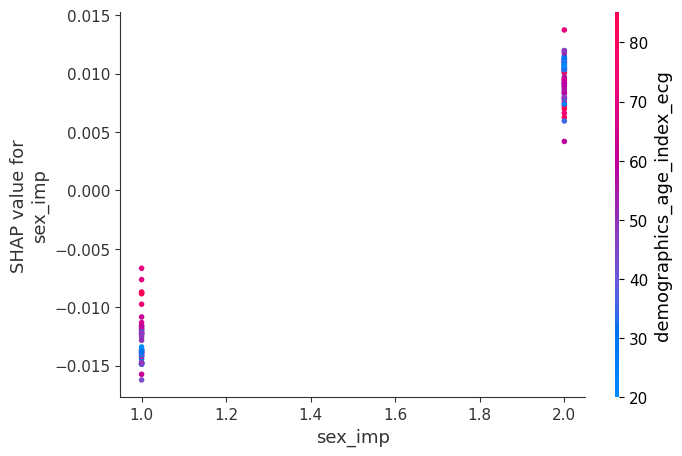

In [4]:
shap.dependence_plot(
    "sex_imp",
    shap_all_kernel,
    X_explain_df,
    interaction_index="demographics_age_index_ecg"
)

In [9]:
### Cumulative risk
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchtuples as tt

from einops import rearrange, repeat
from torch.serialization import add_safe_globals

import tab_transformer_pytorch
from tab_transformer_pytorch.tab_transformer_pytorch import (
    Transformer as InnerTransformer,
    PreNorm as InnerPreNorm,
    Attention as InnerAttention,
    FeedForward as InnerFeedForward,
    GEGLU as InnerGEGLU,
    MLP as InnerMLP,
)

# ==========================================
# 0. REPRODUCIBILITY
# ==========================================
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# ==========================================
# 1. MODEL CLASS DEFINITIONS
# ==========================================
def exists(val):
    return val is not None


class TabTransformerwithEmbedding(tab_transformer_pytorch.TabTransformer):
    def forward(self, x_categ, x_cont, return_attn=False, return_embedding=False):
        xs = []
        assert x_categ.shape[-1] == self.num_categories

        if self.num_unique_categories > 0:
            x_categ = x_categ + self.categories_offset
            categ_embed = self.category_embed(x_categ)

            if self.use_shared_categ_embed:
                shared_categ_embed = repeat(
                    self.shared_category_embed,
                    'n d -> b n d',
                    b=categ_embed.shape[0]
                )
                categ_embed = torch.cat((categ_embed, shared_categ_embed), dim=-1)

            x, attns = self.transformer(categ_embed, return_attn=True)
            flat_categ = rearrange(x, 'b ... -> b (...)')
            xs.append(flat_categ)

        if self.num_continuous > 0:
            if exists(getattr(self, 'continuous_mean_std', None)):
                mean, std = self.continuous_mean_std.unbind(dim=-1)
                x_cont = (x_cont - mean) / std
            normed_cont = self.norm(x_cont)
            xs.append(normed_cont)

        x = torch.cat(xs, dim=-1)
        x = self.embedding_proj(x)

        if return_embedding:
            if return_attn:
                return x, attns
            return x

        logits = self.mlp(x)
        if return_attn:
            return logits, attns
        return logits


class TabTransformerSharedCauseSpecificNet(nn.Module):
    def __init__(
        self,
        tab_net,
        embed_dim,
        num_nodes_shared,
        num_nodes_indiv,
        num_risks,
        out_features,
        dropout=0.1
    ):
        super().__init__()
        self.tab = TabTransformerwithEmbedding(**tab_net)

        self.shared_mlp = tt.practical.MLPVanilla(
            embed_dim,
            num_nodes_shared[:-1],
            num_nodes_shared[-1],
            batch_norm=True,
            dropout=dropout
        )

        self.risk_nets = nn.ModuleList([
            tt.practical.MLPVanilla(
                num_nodes_shared[-1],
                num_nodes_indiv,
                out_features,
                batch_norm=True,
                dropout=dropout
            )
            for _ in range(num_risks)
        ])

    def forward(self, x_cat, x_cont):
        x_embed = self.tab(x_cat, x_cont, return_embedding=True)
        shared_out = self.shared_mlp(x_embed)
        out = [risk_net(shared_out) for risk_net in self.risk_nets]
        return torch.stack(out, dim=1)


# ==========================================
# 2. PATCH TABTRANSFORMER INTERNAL SYMBOLS
# ==========================================
setattr(tab_transformer_pytorch, "Transformer", InnerTransformer)
setattr(tab_transformer_pytorch, "PreNorm", InnerPreNorm)
setattr(tab_transformer_pytorch, "Attention", InnerAttention)
setattr(tab_transformer_pytorch, "FeedForward", InnerFeedForward)
setattr(tab_transformer_pytorch, "GEGLU", InnerGEGLU)
setattr(tab_transformer_pytorch, "MLP", InnerMLP)

# ==========================================
# 3. DATA LOADING
# ==========================================
os.chdir('/home/UT_shared/data/')
print("Loading data...")

df_test = pd.read_csv("test.csv")
df = pd.read_csv("/home/UT_shared/data/df_imputed.csv")
dict_df = pd.read_csv('/home/UHN/Data dictionary_for_UofT_final.csv')

# Fix one variable name if needed
dict_df.loc[15, "Variable name"] = "obstructive._sleep_apnea_icd10"

# Get categorical / continuous variable names from dictionary
categ_vars = dict_df.loc[
    dict_df["Variable type"].isin(["boolean", "categorical"]),
    "Variable name"
].tolist()

cont_vars = dict_df.loc[
    dict_df["Variable type"] == "numeric",
    "Variable name"
].tolist()

# Convert variable names to indices based on df
categ_idx_1 = [df.columns.get_loc(v) for v in categ_vars if v in df.columns]
cont_idx = [df.columns.get_loc(v) for v in cont_vars if v in df.columns]

# Manually force some variables into categorical
vars_to_add = ['sex_imp', 'acei_arb_entresto', 'acute_mi_angina_other']
categ_idx = categ_idx_1.copy()
for v in vars_to_add:
    if v in df.columns:
        idx = df.columns.get_loc(v)
        if idx not in categ_idx:
            categ_idx.append(idx)

print("Number of categorical features:", len(categ_idx))
print("Number of continuous features:", len(cont_idx))

# Sanity check: unused variables
all_used_idx = set(categ_idx) | set(cont_idx)
other_idx = [i for i in range(len(df.columns)) if i not in all_used_idx]
other_vars = df.columns[other_idx].tolist()
print("Unused variables:", other_vars)

# IMPORTANT:
# This assumes df_test has same column structure/order as model input source
feature_names_ordered = df_test.columns[categ_idx].tolist() + df_test.columns[cont_idx].tolist()
X_all = df_test.iloc[:, categ_idx + cont_idx].to_numpy()

# ==========================================
# 4. LOAD MODEL
# ==========================================
print("Loading model...")
add_safe_globals([TabTransformerwithEmbedding, TabTransformerSharedCauseSpecificNet])

model_path = "/home/UT_shared/final_model/end-lr0.0001-wd0.01-eta0.8-alpha0.2-bs256-drop0.1-epochs100-dur30-embed500.pt"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

net = torch.load(model_path, map_location=device, weights_only=False)
net.eval()
net.to(device)
with torch.no_grad():
    x_cat = torch.tensor(df_test.iloc[:2, categ_idx].to_numpy(), dtype=torch.long, device=device)
    x_cont = torch.tensor(df_test.iloc[:2, cont_idx].to_numpy(), dtype=torch.float32, device=device)

    preds = net(x_cat, x_cont)
    print("Pred shape:", preds.shape)

print("Model loaded on:", device)

# ==========================================
# 5. SETTINGS FOR CUMULATIVE RISK
# ==========================================
# risk_idx: which event/cause to explain
# time_idx: cumulative risk up to and including this time index
risk_idx = 1
time_idx = 25

print(f"Explaining cumulative risk for event {risk_idx} up to time_idx {time_idx}")

# ==========================================
# 6. HELPER FUNCTIONS
# ==========================================
def get_cumulative_risk(cat_np, cont_np, model, risk_idx=0, time_idx=25):
    """
    Return cumulative risk = sum of probabilities for event risk_idx
    from time 0 to time_idx inclusive.

    Input:
      cat_np: numpy array, shape [n, n_cat]
      cont_np: numpy array, shape [n, n_cont]

    Output:
      numpy array, shape [n]
    """
    with torch.no_grad():
        x_cat = torch.tensor(cat_np, dtype=torch.long, device=device)
        x_cont = torch.tensor(cont_np, dtype=torch.float32, device=device)

        preds = model(x_cat, x_cont)              # [batch, num_risks, out_features]
        prob = F.softmax(preds, dim=2)            # probability over time bins
        cum_risk = prob[:, risk_idx, :time_idx + 1].sum(dim=1)

        return cum_risk.cpu().numpy()


def predict_cumulative_risk_fn(risk_idx=1, time_idx=25):
    """
    Function wrapper for shap.KernelExplainer.
    Input must be combined matrix:
      [categorical columns first | continuous columns second]
    """
    def fn(x_combined_numpy):
        with torch.no_grad():
            n_cat = len(categ_idx)

            x_cat = torch.tensor(
                x_combined_numpy[:, :n_cat],
                dtype=torch.long,
                device=device
            )
            x_cont = torch.tensor(
                x_combined_numpy[:, n_cat:],
                dtype=torch.float32,
                device=device
            )

            preds = net(x_cat, x_cont)
            prob = F.softmax(preds, dim=2)
            cum_risk = prob[:, risk_idx, :time_idx + 1].sum(dim=1)

            return cum_risk.cpu().numpy()

    return fn

# ==========================================
# 7. PERMUTATION IMPORTANCE FOR CUMULATIVE RISK
# ==========================================
print("Running permutation importance for cumulative risk...")

n_samples_perm = 3000
n_repeats_perm = 5

rng = np.random.default_rng(SEED)
indices = rng.choice(len(df_test), size=min(n_samples_perm, len(df_test)), replace=False)

x_cat_baseline = df_test.iloc[indices, categ_idx].to_numpy()
x_cont_baseline = df_test.iloc[indices, cont_idx].to_numpy()

base_preds = get_cumulative_risk(
    x_cat_baseline,
    x_cont_baseline,
    net,
    risk_idx=risk_idx,
    time_idx=time_idx
)

feature_importance = {}

# Categorical features
print("Permuting categorical features...")
cat_names = df_test.columns[categ_idx].tolist()

for i, name in enumerate(cat_names):
    scores = []
    for _ in range(n_repeats_perm):
        x_cat_shuffled = x_cat_baseline.copy()
        perm = rng.permutation(x_cat_shuffled.shape[0])
        x_cat_shuffled[:, i] = x_cat_shuffled[perm, i]

        new_preds = get_cumulative_risk(
            x_cat_shuffled,
            x_cont_baseline,
            net,
            risk_idx=risk_idx,
            time_idx=time_idx
        )

        importance = np.mean(np.abs(new_preds - base_preds))
        scores.append(importance)

    feature_importance[name] = float(np.mean(scores))

# Continuous features
print("Permuting continuous features...")
cont_names = df_test.columns[cont_idx].tolist()

for i, name in enumerate(cont_names):
    scores = []
    for _ in range(n_repeats_perm):
        x_cont_shuffled = x_cont_baseline.copy()
        perm = rng.permutation(x_cont_shuffled.shape[0])
        x_cont_shuffled[:, i] = x_cont_shuffled[perm, i]

        new_preds = get_cumulative_risk(
            x_cat_baseline,
            x_cont_shuffled,
            net,
            risk_idx=risk_idx,
            time_idx=time_idx
        )

        importance = np.mean(np.abs(new_preds - base_preds))
        scores.append(importance)

    feature_importance[name] = float(np.mean(scores))

# Save permutation results
imp_df = pd.DataFrame(
    list(feature_importance.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)

perm_csv_path = "/home/yu10-shi/permutation_importance_cumrisk_values.csv"
imp_df.to_csv(perm_csv_path, index=False)
print(f"Saved permutation values to: {perm_csv_path}")

# Plot top 20
top_df = imp_df.tail(20)

plt.figure(figsize=(10, 12))
plt.barh(top_df['Feature'], top_df['Importance'])
plt.xlabel("Mean Absolute Change in Cumulative Risk")
plt.title(f"Permutation Importance for AF (Top 20 Features)")
plt.tight_layout()
perm_plot_path = "/home/yu10-shi/permutation_importance_cumrisk_plot.png"
plt.savefig(perm_plot_path, dpi=300)
plt.close()
print(f"Saved permutation plot to: {perm_plot_path}")

print("\nTop 10 Features from permutation:")
print(imp_df.tail(10).sort_values(by='Importance', ascending=False))

# ==========================================
# 8. KERNEL SHAP FOR CUMULATIVE RISK
# ==========================================
print("Running Kernel SHAP for cumulative risk...")

top_10_features = (
    imp_df.sort_values(by='Importance', ascending=False)
    .head(10)['Feature']
    .tolist()
)
print("Top 10 features by permutation:", top_10_features)

predict_fn = predict_cumulative_risk_fn(
    risk_idx=risk_idx,
    time_idx=time_idx
)

# Keep modest because Kernel SHAP is slow
n_bg = 100
n_exp = 100

bg_idx = rng.choice(X_all.shape[0], size=min(n_bg, X_all.shape[0]), replace=False)
remaining_idx = np.setdiff1d(np.arange(X_all.shape[0]), bg_idx)

if len(remaining_idx) >= n_exp:
    exp_idx = rng.choice(remaining_idx, size=n_exp, replace=False)
else:
    exp_idx = rng.choice(X_all.shape[0], size=min(n_exp, X_all.shape[0]), replace=False)

background_data = X_all[bg_idx]
X_explain = X_all[exp_idx]
X_explain_df = pd.DataFrame(X_explain, columns=feature_names_ordered)

print("Building KernelExplainer...")
explainer = shap.KernelExplainer(predict_fn, background_data)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_explain, nsamples=100)

shap_all_kernel = np.array(shap_values)

# Handle shape differences across SHAP versions
if shap_all_kernel.ndim == 3 and shap_all_kernel.shape[-1] == 1:
    shap_all_kernel = shap_all_kernel[..., 0]

if shap_all_kernel.shape[0] != X_explain.shape[0] and shap_all_kernel.shape[1] == X_explain.shape[0]:
    shap_all_kernel = shap_all_kernel.T

print("Kernel SHAP shape:", shap_all_kernel.shape)

# Save raw SHAP matrix
kernel_shap_csv = "/home/yu10-shi/kernel_shap_cumrisk_values.csv"
pd.DataFrame(shap_all_kernel, columns=feature_names_ordered).to_csv(kernel_shap_csv, index=False)
print(f"Saved raw Kernel SHAP values to: {kernel_shap_csv}")

# ==========================================
# 9. FILTER TO TOP 10 FEATURES FROM PERMUTATION
# ==========================================
all_shap_cols = X_explain_df.columns.tolist()
top_10_indices = [all_shap_cols.index(feat) for feat in top_10_features]

shap_subset = shap_all_kernel[:, top_10_indices]
X_subset_df = X_explain_df[top_10_features]

# ==========================================
# 10. SHAP BEESWARM PLOT
# ==========================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_subset,
    X_subset_df,
    plot_type="dot",
    max_display=10,
    show=False
)
plt.title(f"SHAP Beeswarm for AF (Top 10 Features)")
plt.tight_layout()
kernel_beeswarm_path = "/home/yu10-shi/kernel_shap_cumrisk_top10_beeswarm.png"
plt.savefig(kernel_beeswarm_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved Kernel SHAP beeswarm plot to: {kernel_beeswarm_path}")

# ==========================================
# 11. SHAP BAR PLOT
# ==========================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_subset,
    X_subset_df,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.title(f"SHAP Bar Plot for AF (Top 10 Features)")
plt.tight_layout()
kernel_bar_path = "/home/yu10-shi/kernel_shap_cumrisk_top10_bar.png"
plt.savefig(kernel_bar_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved Kernel SHAP bar plot to: {kernel_bar_path}")

# ==========================================
# 12. OPTIONAL: SEX DEPENDENCE PLOT FOR CUMULATIVE RISK
# ==========================================
if "sex_imp" in X_explain_df.columns:
    sex_idx = X_explain_df.columns.get_loc("sex_imp")

    interaction_var = "demographics_age_index_ecg"
    if interaction_var in X_explain_df.columns:
        plt.figure(figsize=(8, 6))
        shap.dependence_plot(
            sex_idx,
            shap_all_kernel,
            X_explain_df,
            interaction_index=interaction_var,
            show=False
        )
        plt.title(f"SHAP Dependence Plot for sex_imp\nCumulative Risk (event={risk_idx}, time_idx={time_idx})")
        dep_path = "/home/yu10-shi/shap_dependence_sex_cumrisk.png"
        plt.tight_layout()
        plt.savefig(dep_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved SHAP dependence plot to: {dep_path}")

print("Done.")


Loading data...
Number of categorical features: 61
Number of continuous features: 17
Unused variables: ['status', 'year']
Loading model...
Pred shape: torch.Size([2, 2, 30])
Model loaded on: cuda
Explaining cumulative risk for event 1 up to time_idx 25
Running permutation importance for cumulative risk...
Permuting categorical features...
Permuting continuous features...
Saved permutation values to: /home/yu10-shi/permutation_importance_cumrisk_values.csv
Saved permutation plot to: /home/yu10-shi/permutation_importance_cumrisk_plot.png

Top 10 Features from permutation:
                       Feature  Importance
58                     sex_imp    0.296373
61  demographics_age_index_ecg    0.054959
70    alkaline_phophatase_peri    0.030850
66                    hgb_peri    0.025388
18            cancer_any_icd10    0.018162
2        dyslipidemia_combined    0.016948
65             ecg_resting_qtc    0.014604
73             creatinine_peri    0.008452
62              ecg_resting_hr    0.

100%|██████████| 100/100 [01:07<00:00,  1.49it/s]
/tmp/ipykernel_231/1883095621.py:435: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Kernel SHAP shape: (100, 78)
Saved raw Kernel SHAP values to: /home/yu10-shi/kernel_shap_cumrisk_values.csv
Saved Kernel SHAP beeswarm plot to: /home/yu10-shi/kernel_shap_cumrisk_top10_beeswarm.png
Saved Kernel SHAP bar plot to: /home/yu10-shi/kernel_shap_cumrisk_top10_bar.png


/tmp/ipykernel_231/1883095621.py:453: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved SHAP dependence plot to: /home/yu10-shi/shap_dependence_sex_cumrisk.png
Done.


<Figure size 800x600 with 0 Axes>

In [2]:
!pip install shap

  Using cached shap-0.51.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.64.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
Using cached shap-0.51.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached llvmlite-0.46.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (56.3 MB)
Using cached numba-0.64.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]3/4 [shap]]te]
